# Decision Trees from Scratch: Entropy and Information Gain

The point of this lab was to actually build the machinery a decision tree uses to
pick its splits, instead of calling `.fit()` and moving on. So I implemented
entropy, the weighted information of an attribute, and information gain by hand,
then used them to run the ID3 algorithm on the classic *Play Tennis* dataset and
checked the root split against what scikit-learn chooses.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
np.random.seed(0)


## The dataset

Fourteen days of weather with a yes/no decision on whether to play tennis - small enough to check the maths by hand.

In [2]:
data = pd.DataFrame({
    "outlook":     ["Sunny","Sunny","Overcast","Rain","Rain","Rain","Overcast","Sunny","Sunny","Rain","Sunny","Overcast","Overcast","Rain"],
    "temperature": ["Hot","Hot","Hot","Mild","Cool","Cool","Cool","Mild","Cool","Mild","Mild","Mild","Hot","Mild"],
    "humidity":    ["High","High","High","High","Normal","Normal","Normal","High","Normal","Normal","Normal","High","Normal","High"],
    "wind":        ["Weak","Strong","Weak","Weak","Weak","Strong","Strong","Weak","Weak","Weak","Strong","Strong","Weak","Strong"],
    "play":        ["No","No","Yes","Yes","Yes","No","Yes","No","Yes","Yes","Yes","Yes","Yes","No"],
})
data

,outlook,temperature,humidity,wind,play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


## Entropy

$H(S) = -\sum_i p_i \log_2 p_i$

Entropy is highest when the classes are balanced (maximum uncertainty) and zero
when a node is pure.

In [3]:
def entropy(labels):
    _, counts = np.unique(labels, return_counts=True)
    p = counts / counts.sum()
    return float(-np.sum(p * np.log2(p)))

base_entropy = entropy(data["play"])
print(f"Dataset entropy: {base_entropy:.4f}")
print(f"(9 Yes / 5 No, so we expect something close to {-(9/14)*np.log2(9/14) - (5/14)*np.log2(5/14):.4f})")

Dataset entropy: 0.9403
(9 Yes / 5 No, so we expect something close to 0.9403)


## Weighted information of an attribute

Splitting on an attribute partitions the data by its values. The information
*remaining* after the split is the entropy of each partition weighted by its size:

$I(S, A) = \sum_{v \in A} \frac{|S_v|}{|S|} H(S_v)$

In [4]:
def attribute_info(df, attribute, target="play"):
    total = len(df)
    info = 0.0
    for value in df[attribute].unique():
        subset = df[df[attribute] == value]
        info += (len(subset) / total) * entropy(subset[target])
    return info

def information_gain(df, attribute, target="play"):
    return entropy(df[target]) - attribute_info(df, attribute, target)

for col in ["outlook", "temperature", "humidity", "wind"]:
    print(f"{col:12s} info={attribute_info(data, col):.4f}  gain={information_gain(data, col):.4f}")

outlook      info=0.6935  gain=0.2467
temperature  info=0.9111  gain=0.0292
humidity     info=0.7885  gain=0.1518
wind         info=0.8922  gain=0.0481


The attribute with the highest information gain is the one the tree should split on first. Let's see it.

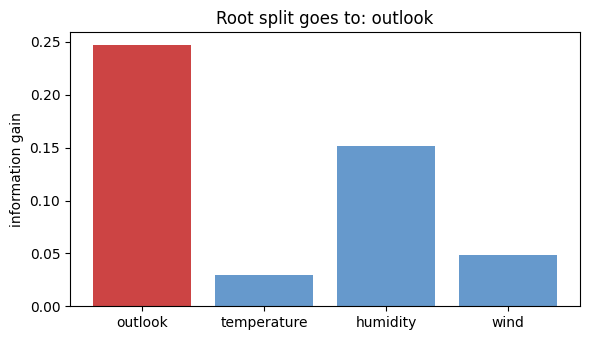

Root attribute: outlook


In [5]:
features = ["outlook", "temperature", "humidity", "wind"]
gains = {c: information_gain(data, c) for c in features}
best = max(gains, key=gains.get)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(gains.keys(), gains.values(), color=["#c44" if k == best else "#69c" for k in gains])
ax.set_ylabel("information gain")
ax.set_title(f"Root split goes to: {best}")
plt.tight_layout(); plt.show()
print("Root attribute:", best)

## ID3, recursively

With gain in hand, ID3 is short: pick the highest-gain attribute, branch on its
values, and recurse until a node is pure or we run out of attributes.

In [6]:
def id3(df, features, target="play"):
    labels = df[target]
    # pure node -> leaf
    if labels.nunique() == 1:
        return labels.iloc[0]
    # no features left -> majority vote
    if not features:
        return labels.mode().iloc[0]
    best = max(features, key=lambda f: information_gain(df, f, target))
    tree = {best: {}}
    for value in sorted(df[best].unique()):
        subset = df[df[best] == value]
        remaining = [f for f in features if f != best]
        tree[best][value] = id3(subset, remaining, target)
    return tree

tree = id3(data, features)

def show(node, indent=0):
    if not isinstance(node, dict):
        print("  " * indent + f"-> {node}")
        return
    attr = next(iter(node))
    for value, child in node[attr].items():
        print("  " * indent + f"[{attr} = {value}]")
        show(child, indent + 1)

show(tree)

[outlook = Overcast]
  -> Yes
[outlook = Rain]
  [wind = Strong]
    -> No
  [wind = Weak]
    -> Yes
[outlook = Sunny]
  [humidity = High]
    -> No
  [humidity = Normal]
    -> Yes


## Sanity check against scikit-learn

sklearn uses the same criterion (entropy), so its root split should match ours.

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OrdinalEncoder

X = OrdinalEncoder().fit_transform(data[features])
y = (data["play"] == "Yes").astype(int)
clf = DecisionTreeClassifier(criterion="entropy", random_state=0).fit(X, y)

root_feature = features[clf.tree_.feature[0]]
print("scikit-learn's root split:", root_feature)
print("our root split:           ", best)
print("match:", root_feature == best)

scikit-learn's root split: outlook
our root split:            outlook
match: True


## Takeaway

Doing this by hand makes the split criterion concrete: *outlook* wins the root
because it carves the data into the purest partitions (Overcast is already a pure
"Yes"). Everything a library does on top - Gini vs. entropy, pruning, continuous
splits - is a refinement of this same greedy, gain-driven idea.
